# Week 2: Qbias Dataset Exploration and Classifier Evaluation

This notebook has two parts:

1. **Dataset exploration** - understand the Qbias data before writing any training code
2. **Classifier evaluation** - run after `training/fine_tune.py` completes; F1 scores, confusion matrix, confidence histogram, threshold derivation

I always explore training data first. If there are quality issues, class imbalance problems, or unexpected patterns, I want to catch them before a two-hour training run.

---
## Part 1: Dataset Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

DATA_PATH = "../data/allsides/allsides_balanced_news_headlines-texts.csv"

# label mapping - converting string labels to integers for PyTorch
# PyTorch expects integer class indices (0, 1, 2), not strings
LABEL2ID = {"left": 0, "center": 1, "right": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

### 1.1 Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  {col}")

Rows:    21,754
Columns: 7

Column names:
  Unnamed: 0
  title
  tags
  heading
  source
  text
  bias_rating


In [3]:
# show one full row transposed so all columns are visible
pd.set_option("display.max_colwidth", 400)
df.head(1).T

,0
Unnamed: 0,0
title,Gun Violence Over Fourth of July Weekend
tags,"['Protests', 'Fourth Of July', 'Gun Control And Gun Rights', 'Chicago', 'Violence In America']"
heading,Chicago Gun Violence Spikes and Increasingly Finds the Youngest Victims
source,New York Times (News)
text,"As Yasmin Miller drove home from a laundromat in Chicago’s Englewood neighborhood last weekend, a gunman in another car peppered her red Hyundai sedan with bullets, grazing her head and striking her son, Sincere Gaston, in the chest. Sincere died in his car seat. He was 20 months old.\nOn June 20, a man fired gunshots through the back of a dark blue SUV, wounding the 27-year-old man driving an..."
bias_rating,left


The columns I care about for training:
- `heading` - the article headline
- `text` - article body (I'll check the length below - this turns out to be short)
- `bias_rating` - the label: `left`, `center`, or `right`
- `source` - outlet name, useful for analysis but not used in training

The `title` column is the AllSides topic name (e.g. "Gun Violence Over Fourth of July Weekend"), not the article headline. `heading` is the article headline.

### 1.2 Data quality check

In [4]:
# null counts per column
null_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct":   (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_summary)

             null_count  null_pct
Unnamed: 0            0      0.00
title                 0      0.00
tags                  0      0.00
heading               0      0.00
source                8      0.04
text                  7      0.03
bias_rating           0      0.00


In [5]:
# check for duplicate articles - two rows with the same headline or the same body text
dup_headings = df.duplicated(subset=["heading"]).sum()
dup_texts    = df.duplicated(subset=["text"]).sum()

print(f"Duplicate headings: {dup_headings}")
print(f"Duplicate body texts: {dup_texts}")
print(f"\nTotal rows before dropping: {len(df):,}")

# drop rows with null text (can't train on empty input)
# drop duplicate texts (same article appearing twice would leak into val/test)
df = df.dropna(subset=["text", "heading"])
df = df.drop_duplicates(subset=["text"])
df = df.reset_index(drop=True)

print(f"Total rows after cleaning:  {len(df):,}")

Duplicate headings: 29
Duplicate body texts: 30

Total rows before dropping: 21,754
Total rows after cleaning:  21,723


### 1.3 Label distribution

Class balance matters a lot for classification. If the dataset is heavily skewed toward one class, the model can achieve high accuracy by just predicting the majority class every time - which is useless. I check this now.

In [6]:
counts = df["bias_rating"].value_counts().reindex(["left", "center", "right"])

print("Article counts by label:")
for label, count in counts.items():
    pct = count / len(df) * 100
    print(f"  {label:8s}: {count:,}  ({pct:.1f}%)")
print(f"  {'TOTAL':8s}: {counts.sum():,}")

Article counts by label:
  left    : 10,260  (47.2%)
  center  : 4,249  (19.6%)
  right   : 7,214  (33.2%)
  TOTAL   : 21,723


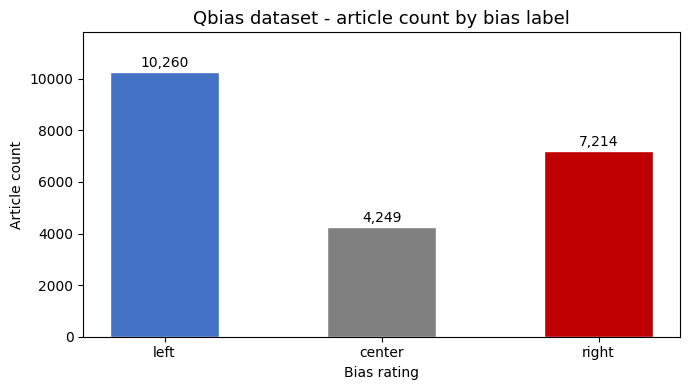

In [7]:
# visualise label distribution
# blue = left, grey = center, red = right - consistent with political convention
colors = ["#4472C4", "#808080", "#C00000"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.5)

# add count labels above each bar
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{val:,}",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Qbias dataset - article count by bias label", fontsize=13)
ax.set_xlabel("Bias rating")
ax.set_ylabel("Article count")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Class imbalance and why it matters for the metric choice:**

`center` has roughly half the articles of `left`. This is real imbalance. If the model learns to mostly predict `left` and `right` and struggles with `center`, overall accuracy can still look decent - but that would be a bad model.

**Macro F1-score** is the right primary metric here. It computes F1 separately for each class and then averages them, giving each class equal weight regardless of how many samples it has. If the model ignores `center`, macro F1 punishes it hard. Accuracy would not.

I'll use `macro` in `sklearn.metrics.f1_score(average='macro')` during evaluation.

### 1.4 Text length analysis

RoBERTa has a hard limit of 512 tokens per input. I need to know how long these articles are to decide how much to truncate.

In [8]:
# compute word and character counts for each article body
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()

print("Word count per article (body text only):")
print(df["word_count"].describe().round(1))
print()
print("Character count per article (body text only):")
print(df["char_count"].describe().round(1))

Word count per article (body text only):
count    21723.0
mean        66.3
std         28.4
min          1.0
25%         37.0
50%         86.0
75%         90.0
max        125.0
Name: word_count, dtype: float64

Character count per article (body text only):
count    21723.0
mean       413.5
std        177.4
min          5.0
25%        232.0
50%        510.0
75%        564.0
max        821.0
Name: char_count, dtype: float64


**Important finding:** These are short excerpts, not full articles. The median body text is around 86 words / 509 characters. AllSides publishes article roundups with excerpts, so the Qbias scraper captured those excerpts, not full article bodies.

This creates a **train/serve mismatch**: I train on short excerpts but at inference time (in `src/classifier.py`) I pass full articles scraped by `newspaper3k`. The model will see longer, more complete text at inference time than it was trained on.

This is a real limitation - I'll acknowledge it in the README. The practical impact is that the first ~500 characters of the article (which overlaps with what training saw) will carry the most weight in predictions.

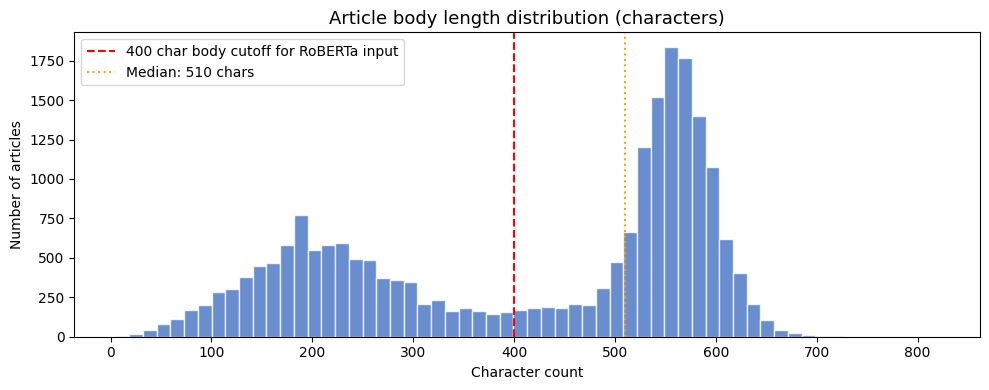

Articles fully covered by 400 chars: 8,932 (41.1%)


In [9]:
# plot character length distribution
# the red dashed line shows the 400-char cutoff I'll use for the RoBERTa body input
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["char_count"], bins=60, color="#4472C4", edgecolor="white", alpha=0.8)
ax.axvline(
    400, color="red", linestyle="--", linewidth=1.5,
    label=f"400 char body cutoff for RoBERTa input"
)
ax.axvline(
    df["char_count"].median(), color="orange", linestyle=":", linewidth=1.5,
    label=f"Median: {df['char_count'].median():.0f} chars"
)
ax.set_title("Article body length distribution (characters)", fontsize=13)
ax.set_xlabel("Character count")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

# how many articles are fully covered by the 400-char input?
fully_covered = (df["char_count"] <= 400).sum()
print(f"Articles fully covered by 400 chars: {fully_covered:,} ({fully_covered/len(df)*100:.1f}%)")

### 1.5 Sample articles from each class

Before writing any code, I read some actual examples. This is the most important step in understanding training data - numbers and charts tell you the shape, but reading actual articles tells you whether the labels make sense.

In [10]:
# show one sample article from each bias class
for label in ["left", "center", "right"]:
    sample = df[df["bias_rating"] == label].sample(1, random_state=42).iloc[0]
    print("=" * 65)
    print(f"LABEL:    {label.upper()}")
    print(f"Source:   {sample['source']}")
    print(f"Topic:    {sample['title']}")
    print(f"Headline: {sample['heading']}")
    print(f"Body:     {sample['text'][:300]}...")
    print()

LABEL:    LEFT
Source:   USA TODAY
Topic:    Analysis From Day Two of Public Impeachment Hearings
Headline: Intimidation among key takeaways from the Trump impeachment hearing with Marie Yovanovitch
Body:     WASHINGTON – Marie Yovanovitch told lawmakers she had only U.S. interests in mind while serving as ambassador to Ukraine at an impeachment inquiry hearing Friday during which President Donald Trump tweeted insults at her.
Yovanovitch, 61, also tried to dismiss debunked GOP claims that Ukraine meddle...

LABEL:    CENTER
Source:   Forbes
Topic:    Trump Vetoes Defense Spending Bill
Headline: Trump Vetoes Broadly Supported Defense Bill As He Battles Congress On Multiple Fronts
Body:     President Donald Trump on Wednesday followed through on his threat to veto the annual defense spending bill, which was passed by Congress with broad bipartisan support, as he clashes with lawmakers – and Senate GOP leadership in particular – on a stimulus bill and the election. The National Defense .

### 1.6 The RoBERTa input format

RoBERTa takes a single string as input. I concatenate the headline and body text with `</s>` as a separator.

Why `</s>` and not `[SEP]`? Because `</s>` is RoBERTa's separator token. BERT uses `[SEP]`. They're different models with different tokenizers - using `[SEP]` with RoBERTa would pass it through as an unknown token, not a separator signal.

In [11]:
# build the input string for one example to see what fine_tune.py will feed to RoBERTa
sample = df.sample(1, random_state=7).iloc[0]

# format: headline + separator token + first 400 chars of body
roberta_input = f"{sample['heading']} </s> {sample['text'][:400]}"

print(f"Label:  {sample['bias_rating']}")
print(f"Source: {sample['source']}")
print()
print("RoBERTa input string:")
print("-" * 65)
print(roberta_input)
print("-" * 65)
print(f"\nTotal characters: {len(roberta_input)}")

Label:  center
Source: RealClearPolitics

RoBERTa input string:
-----------------------------------------------------------------
Sanders Campaign Organizer: Free Education, Gulags Needed To "Re-Educate" You To Not Be A "F*cking Nazi" </s> A campaign organizer for Democratic presidential candidate Bernie Sanders warned about mass violence and advocated for the use of gulags for "re-education" in a conversation caught on tape by James O’Keefe’s Project Veritas. In the undercover video, Kyle Jurek, an Iowa field organizer for the Sanders campaign, said the country will have to "spend billions" on re-education for people that are "Nazi
-----------------------------------------------------------------

Total characters: 510


### 1.7 Label encoding and train/val/test split

I convert string labels to integers and split into three sets:
- **Train (80%)** - what the model learns from
- **Val (10%)** - used during training to pick the best checkpoint (I save based on val macro F1, not train loss)
- **Test (10%)** - held out completely; only used once at the end for final reported metrics

I use `stratify` to ensure each split has the same class distribution as the full dataset.

In [12]:
# add integer label column
df["label"] = df["bias_rating"].map(LABEL2ID)

print("Label mapping:")
for k, v in LABEL2ID.items():
    print(f"  '{k}' -> {v}")
print(f"\nNull labels (any unmapped strings): {df['label'].isnull().sum()}")

Label mapping:
  'left' -> 0
  'center' -> 1
  'right' -> 2

Null labels (any unmapped strings): 0


In [13]:
# 80/10/10 split with stratification
# stratify=df["bias_rating"] means each split gets the same left/center/right proportions
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["bias_rating"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["bias_rating"], random_state=42
)

print(f"Train: {len(train_df):,} articles")
print(f"Val:   {len(val_df):,} articles")
print(f"Test:  {len(test_df):,} articles")
print()
print("Class distribution in each split (should be ~the same):")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    dist = split["bias_rating"].value_counts().reindex(["left", "center", "right"])
    pcts = (dist / len(split) * 100).round(1)
    row = "  |  ".join(f"{lbl}: {dist[lbl]:,} ({pcts[lbl]}%)" for lbl in ["left", "center", "right"])
    print(f"  {name:5s}: {row}")

Train: 17,378 articles
Val:   2,172 articles
Test:  2,173 articles

Class distribution in each split (should be ~the same):
  Train: left: 8,208 (47.2%)  |  center: 3,399 (19.6%)  |  right: 5,771 (33.2%)
  Val  : left: 1,026 (47.2%)  |  center: 425 (19.6%)  |  right: 721 (33.2%)
  Test : left: 1,026 (47.2%)  |  center: 425 (19.6%)  |  right: 722 (33.2%)


In [14]:
# save splits to data/processed/ so fine_tune.py loads them directly
# this ensures training and evaluation always use the same split
os.makedirs("../data/processed", exist_ok=True)

train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv",   index=False)
test_df.to_csv("../data/processed/test.csv",  index=False)

print("Saved to data/processed/:")
print(f"  train.csv  ({len(train_df):,} rows)")
print(f"  val.csv    ({len(val_df):,} rows)")
print(f"  test.csv   ({len(test_df):,} rows)")

Saved to data/processed/:
  train.csv  (17,378 rows)
  val.csv    (2,172 rows)
  test.csv   (2,173 rows)


---
## Part 2: Classifier Evaluation

**Run this section after `training/fine_tune.py` completes.** The model checkpoint will be saved to `models/bias_classifier/`.

What I'll do here:
1. Load the fine-tuned model and run inference on the held-out test set
2. Compute macro F1, per-class precision/recall/F1, and overall accuracy
3. Plot a confusion matrix
4. Plot a confidence score histogram (correct vs. incorrect predictions)
5. Derive the confidence threshold empirically from the histogram

In [15]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
import numpy as np

MODEL_PATH = "../models/bias_classifier"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

/home/skanda_suresh/Projects/news-lens/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [16]:
# load the fine-tuned tokenizer and model from the saved checkpoint
# AutoTokenizer and AutoModelForSequenceClassification automatically detect
# the model type from the config.json saved alongside the weights
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model     = model.to(DEVICE)
model.eval()  # put in eval mode - disables dropout, which is only used during training
print("Model loaded.")

ValueError: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.

In [ ]:
# load the held-out test set
test_df = pd.read_csv("../data/processed/test.csv")
print(f"Test set size: {len(test_df):,} articles")

In [ ]:
def predict_batch(texts, batch_size=32):
    """Run inference on a list of input strings. Returns predicted labels and confidence scores."""
    all_preds  = []
    all_confs  = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        # tokenize: truncate to 512 tokens, pad shorter sequences to the same length
        encoded = tokenizer(
            batch,
            truncation=True,
            max_length=512,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():  # no_grad skips gradient computation - faster and uses less memory
            logits = model(**encoded).logits  # raw unnormalised scores per class

        # softmax converts logits to probabilities that sum to 1.0
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

        # argmax picks the highest-probability class as the prediction
        preds = probs.argmax(axis=1)

        # confidence = probability of the predicted class
        confs = probs.max(axis=1)

        all_preds.extend(preds.tolist())
        all_confs.extend(confs.tolist())

    return all_preds, all_confs

# build input strings in the same format used during training
input_texts = [
    f"{row['heading']} </s> {str(row['text'])[:400]}"
    for _, row in test_df.iterrows()
]

print("Running inference on test set...")
pred_ids, confidences = predict_batch(input_texts)
print("Done.")

In [ ]:
# convert integer predictions back to label strings
pred_labels = [ID2LABEL[p] for p in pred_ids]
true_labels = test_df["bias_rating"].tolist()

# overall accuracy and macro F1
acc      = accuracy_score(true_labels, pred_labels)
macro_f1 = f1_score(true_labels, pred_labels, average="macro")

print(f"Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro F1:  {macro_f1:.4f}  (primary metric - equal weight to each class)")
print()
print("Per-class report:")
# labels= fixes sklearn's default alphabetical sort so left/center/right map correctly
print(classification_report(true_labels, pred_labels, labels=["left", "center", "right"], target_names=["left", "center", "right"]))

In [ ]:
# confusion matrix
# rows = true label, columns = predicted label
# a perfect classifier would have all counts on the diagonal
labels_ordered = ["left", "center", "right"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_ordered)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix - bias classifier (test set)")
plt.tight_layout()
plt.show()

### Confidence score distribution and threshold derivation

The model outputs a confidence score (0-1) for every prediction. High confidence usually means the model is right. Low confidence usually means the article is ambiguous or the model is uncertain.

I want to find a threshold below which the error rate is too high. Predictions below that threshold get flagged as "uncertain" in the dashboard - shown with a grey/striped label rather than a hard left/center/right label.

**How to pick the threshold:** plot confidence distributions for correct and incorrect predictions. Find the confidence level where incorrect predictions start to dominate. That is the threshold.

In [ ]:
# separate confidence scores for correct vs. incorrect predictions
correct_mask = [p == t for p, t in zip(pred_labels, true_labels)]
correct_confs   = [c for c, ok in zip(confidences, correct_mask) if ok]
incorrect_confs = [c for c, ok in zip(confidences, correct_mask) if not ok]

print(f"Correct predictions:   {len(correct_confs):,}")
print(f"Incorrect predictions: {len(incorrect_confs):,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(correct_confs,   bins=40, alpha=0.6, color="green", label="Correct predictions")
ax.hist(incorrect_confs, bins=40, alpha=0.6, color="red",   label="Incorrect predictions")
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.set_title("Confidence score distribution - correct vs. incorrect predictions")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# compute error rate in each confidence bin
# I want to find the confidence level where error rate drops to an acceptable level
bins = np.arange(0.0, 1.01, 0.05)  # bins from 0.0 to 1.0 in steps of 0.05
bin_labels  = []
bin_errors  = []
bin_totals  = []

for lo, hi in zip(bins[:-1], bins[1:]):
    in_bin = [
        (p == t)
        for p, t, c in zip(pred_labels, true_labels, confidences)
        if lo <= c < hi
    ]
    if len(in_bin) == 0:
        continue
    error_rate = 1 - (sum(in_bin) / len(in_bin))
    bin_labels.append(f"{lo:.2f}-{hi:.2f}")
    bin_errors.append(error_rate)
    bin_totals.append(len(in_bin))

print(f"{'Confidence bin':<15} {'Error rate':>12} {'N articles':>12}")
print("-" * 42)
for bl, er, nt in zip(bin_labels, bin_errors, bin_totals):
    flag = " <-- high error" if er > 0.35 else ""
    print(f"{bl:<15} {er:>11.1%} {nt:>12,}{flag}")

In [ ]:
# threshold derived from the error rate table above:
# below 0.85 the error rate stays above 29%, which is too high for a confident label
# at 0.85+, error rate drops to ~15% and below - that's the region worth trusting
CONFIDENCE_THRESHOLD = 0.85

trusted   = sum(1 for c in confidences if c >= CONFIDENCE_THRESHOLD)
uncertain = sum(1 for c in confidences if c <  CONFIDENCE_THRESHOLD)

trusted_correct = sum(
    1 for p, t, c in zip(pred_labels, true_labels, confidences)
    if c >= CONFIDENCE_THRESHOLD and p == t
)

print(f"Threshold: {CONFIDENCE_THRESHOLD}")
print(f"Trusted predictions   (conf >= {CONFIDENCE_THRESHOLD}): {trusted:,}   ({trusted/len(confidences)*100:.1f}%)")
print(f"Uncertain predictions (conf <  {CONFIDENCE_THRESHOLD}): {uncertain:,} ({uncertain/len(confidences)*100:.1f}%)")
print()
if trusted > 0:
    trusted_acc = trusted_correct / trusted
    print(f"Accuracy on trusted predictions: {trusted_acc:.4f} ({trusted_acc*100:.2f}%)")
print()
print(f"Use CONFIDENCE_THRESHOLD = {CONFIDENCE_THRESHOLD} in src/classifier.py")